# 13 — 1D CNN Autoencoder Baseline

Symmetric 1D-CNN autoencoder. Encoder: Conv1D + MaxPool1D halves the time
axis twice (100 → 50 → 25) and compresses to 8 channels at the bottleneck.
Decoder mirrors this with UpSampling1D and a final linear Conv1D for
reconstruction.

**Inputs**: arrays from `data/processed/bootcamp/` (run `run_preprocessing_bootcamp()`)
**Outputs**: `models/cnn_ae_bootcamp.keras`

Pipeline parallel to NB 12 (LSTM-AE) so the two non-linear baselines are
directly comparable; comparison to NB 11 (PCA) is the linear-vs-non-linear
axis on the same test_intern split.

**Sections**
0. Setup & Imports
1. Load bootcamp arrays
2. Build and train CNN-AE on `FIT_SIZE` subsampled windows
3. Score val + test_intern via `score_windows`
4. Tune threshold on val via `tune_threshold`
5. Evaluate on test_intern — five-metric table
6. Bootstrap CI on test_intern event-F0.5
7. Save model artifact
8. Summary

## 0 — Setup & Imports

In [1]:
import sys, json, time, os
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sentinel.ml_logic.scoring    import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import (
    event_f05, corrected_event_f05, row_precision_recall,
)
from sentinel.ml_logic.validation import bootstrap_f05_ci
from sentinel.params import (
    FIT_SIZE, RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)

tf.keras.utils.set_random_seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

BOOTCAMP_DIR    = Path('../data/processed/bootcamp')
MODELS_DIR      = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

print(f'TF {tf.__version__}   GPUs: {tf.config.list_physical_devices("GPU")}')
print(f'FIT_SIZE = {FIT_SIZE!r}')

TF 2.16.2   GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
FIT_SIZE = 50000


---
## 1 — Load Bootcamp Arrays

In [2]:
with open(BOOTCAMP_DIR / 'bootcamp_config.json') as f:
    cfg = json.load(f)

WIN    = cfg['window_size']
N_FEAT = cfg['n_features']
assert WIN == WINDOW_SIZE, f'window mismatch: {WIN} vs {WINDOW_SIZE}'

X_train_nom = np.load(BOOTCAMP_DIR / 'X_train_nom.npy')
val_scaled  = np.load(BOOTCAMP_DIR / 'val_scaled.npy')
y_val       = np.load(BOOTCAMP_DIR / 'y_val.npy')
test_scaled = np.load(BOOTCAMP_DIR / 'test_intern_scaled.npy')
y_test      = np.load(BOOTCAMP_DIR / 'y_test_intern.npy')

print(f'X_train_nom      : {X_train_nom.shape}')
print(f'val_scaled       : {val_scaled.shape}   ({int(y_val.sum()):>7,} anom rows)')
print(f'test_intern      : {test_scaled.shape}   ({int(y_test.sum()):>7,} anom rows)')

X_train_nom      : (92271, 100, 58)
val_scaled       : (2232277, 58)   (246,463 anom rows)
test_intern      : (2186220, 58)   (214,961 anom rows)


---
## 2 — Build and Train CNN-AE

Symmetric Conv1D autoencoder: two MaxPool stages (100 → 50 → 25) with a
bottleneck of 8 channels at the smallest spatial resolution. Adam `lr=1e-3`,
MSE loss, EarlyStopping + ReduceLROnPlateau. Per-window z-normalisation
before the forward pass — same drift-robust recipe as NB 12.

In [3]:
def build_cnn_ae(window_size, n_channels):
    inputs = layers.Input(shape=(window_size, n_channels))

    # Encoder: 100 → 50 → 25
    x = layers.Conv1D(32, 7, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(16, 5, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D( 8, 3, activation='relu', padding='same')(x)   # bottleneck

    # Decoder: 25 → 50 → 100
    x = layers.Conv1D(16, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)
    outputs = layers.Conv1D(n_channels, 7, activation='linear', padding='same')(x)

    model = Model(inputs, outputs, name='cnn_ae_bootcamp')
    model.compile(optimizer=Adam(1e-3), loss='mse')
    return model


def zscore_window(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1,  keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)


model = build_cnn_ae(WIN, N_FEAT)
model.summary()

Model: "cnn_ae_bootcamp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 58)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 32)        │        13,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 16)         │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 25, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 25, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 50, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 58)        │        13,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,034 (125.13 KB)

 Trainable params: 32,034 (125.13 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
if FIT_SIZE is not None and FIT_SIZE < len(X_train_nom):
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(X_train_nom), size=FIT_SIZE, replace=False)
    X_fit_raw = X_train_nom[idx]
    print(f'Training on {len(X_fit_raw):,} subsampled windows (FIT_SIZE={FIT_SIZE:,})')
else:
    X_fit_raw = X_train_nom
    print(f'Training on all {len(X_fit_raw):,} nominal windows')

X_fit = zscore_window(X_fit_raw)
del X_fit_raw

EPOCHS     = 50
BATCH_SIZE = 256
MODEL_PATH = MODELS_DIR / 'cnn_ae_bootcamp.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=0),
]

t0 = time.time()
history = model.fit(
    X_fit, X_fit,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=2, shuffle=True,
)
train_seconds = time.time() - t0
print(f'Trained in {train_seconds/60:.1f} min  ({len(history.history["loss"])} epochs)')
print(f'Model saved → {MODEL_PATH}')

Training on 50,000 subsampled windows (FIT_SIZE=50,000)
Epoch 1/50
176/176 - 21s - 122ms/step - loss: 0.8230 - val_loss: 0.7776 - learning_rate: 0.0010
Epoch 2/50
176/176 - 21s - 119ms/step - loss: 0.7569 - val_loss: 0.7423 - learning_rate: 0.0010
Epoch 3/50
176/176 - 22s - 124ms/step - loss: 0.7341 - val_loss: 0.7273 - learning_rate: 0.0010
Epoch 4/50
176/176 - 20s - 111ms/step - loss: 0.7221 - val_loss: 0.7167 - learning_rate: 0.0010
Epoch 5/50
176/176 - 19s - 108ms/step - loss: 0.7125 - val_loss: 0.7084 - learning_rate: 0.0010
Epoch 6/50
176/176 - 19s - 107ms/step - loss: 0.7059 - val_loss: 0.7035 - learning_rate: 0.0010
Epoch 7/50
176/176 - 19s - 107ms/step - loss: 0.7017 - val_loss: 0.7001 - learning_rate: 0.0010
Epoch 8/50
176/176 - 19s - 107ms/step - loss: 0.6986 - val_loss: 0.6974 - learning_rate: 0.0010
Epoch 9/50
176/176 - 19s - 107ms/step - loss: 0.6964 - val_loss: 0.6955 - learning_rate: 0.0010
Epoch 10/50
176/176 - 19s - 107ms/step - loss: 0.6948 - val_loss: 0.6940 - learn

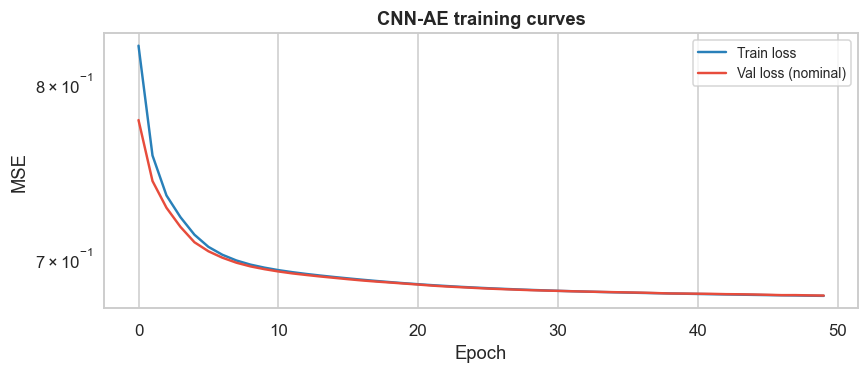

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
h = history.history
ax.plot(h['loss'],     lw=1.6, color=NOMINAL_COLOR, label='Train loss')
ax.plot(h['val_loss'], lw=1.6, color=ANOMALY_COLOR, label='Val loss (nominal)')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('CNN-AE training curves', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 3 — Score Val + test_intern

Same z-normalisation adapter as NB 12: wrap the model so `score_windows` sees
a reconstruction-that-yields-z-space-residual.

In [6]:
class ZNormAdapter:
    '''Wraps a Keras AE trained on z-normalised windows so score_windows sees
    the z-space residual. Given score_windows computes ((X - predict(X))**2),
    we return pred = X - Xn + Xhat so (X - pred) == (Xn - Xhat).'''
    def __init__(self, model):
        self.model = model

    def predict(self, X, batch_size=256, verbose=0):
        Xn   = zscore_window(X)
        Xhat = self.model.predict(Xn, batch_size=batch_size, verbose=verbose)
        return X - Xn + Xhat


scorer = ZNormAdapter(model)

t0 = time.time()
val_scores = score_windows(scorer, val_scaled, win=WIN, batch=256)
print(f'val_scores : {val_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{val_scores.min():.4f}, {val_scores.max():.4f}]')

t0 = time.time()
test_scores = score_windows(scorer, test_scaled, win=WIN, batch=256)
print(f'test_scores: {test_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{test_scores.min():.4f}, {test_scores.max():.4f}]')

val_scores : (2232277,)   (3.3s)   range [0.5863, 0.8041]
test_scores: (2186220,)   (1.6s)   range [0.5879, 0.8207]


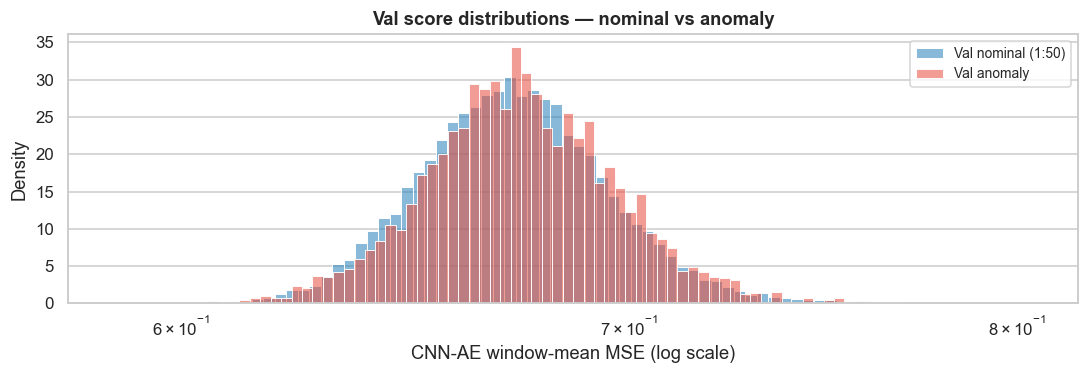

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(val_scores[y_val == 0][::50], ax=ax, color=NOMINAL_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val nominal (1:50)')
sns.histplot(val_scores[y_val == 1], ax=ax, color=ANOMALY_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val anomaly')
ax.set_xlabel('CNN-AE window-mean MSE (log scale)')
ax.set_ylabel('Density')
ax.set_title('Val score distributions — nominal vs anomaly', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 4 — Tune Threshold on Val (event-wise F0.5)

In [8]:
tune = tune_threshold(val_scores, y_val, metric_fn=event_f05, n_sweep=60)
t_best  = tune['threshold']
val_f05 = tune['score']
print(f'Best threshold: {t_best:.6f}   Val event-F0.5: {val_f05:.4f}')

Best threshold: 0.730655   Val event-F0.5: 0.0737


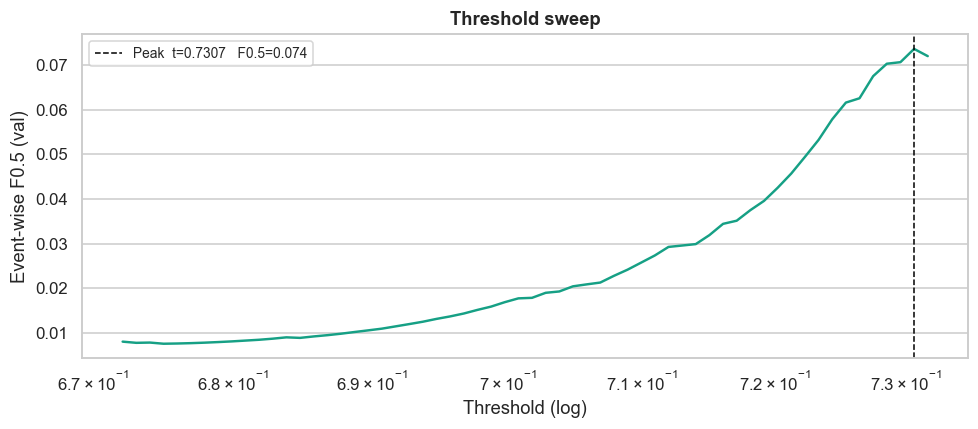

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(tune['sweep_thresholds'], tune['sweep_scores'], lw=1.6, color='#16a085')
ax.axvline(t_best, color='black', ls='--', lw=1,
           label=f'Peak  t={t_best:.4f}   F0.5={val_f05:.3f}')
ax.set_xlabel('Threshold (log)')
ax.set_ylabel('Event-wise F0.5 (val)')
ax.set_title('Threshold sweep', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 5 — Evaluate on test_intern — Five-Metric Table

Same five metrics as NB 11 / NB 12: Event F0.5, Event recall, Event
precision, ESA corrected F0.5, Row F1. Nothing else.

In [10]:
y_pred_test = (test_scores > t_best).astype(np.int8)

ev  = event_f05(y_test, y_pred_test)
esa = corrected_event_f05(y_test, y_pred_test)
rw  = row_precision_recall(y_test, y_pred_test)

metrics = {
    'Event F0.5'        : ev['f_score'],
    'Event recall'      : ev['recall'],
    'Event precision'   : ev['precision'],
    'ESA corrected F0.5': esa['f_score'],
    'Row F1'            : rw['f1'],
}

summary = pd.DataFrame(
    [(k, round(v, 4)) for k, v in metrics.items()],
    columns=['Metric', 'Value'],
)
print(summary.to_string(index=False))

            Metric  Value
        Event F0.5 0.0821
      Event recall 0.6296
   Event precision 0.0675
ESA corrected F0.5 0.0810
            Row F1 0.0407


---
## 6 — Bootstrap CI on test_intern Event-F0.5

In [11]:
t0 = time.time()
ci = bootstrap_f05_ci(y_test, y_pred_test, metric_fn=event_f05,
                      n_boot=200, event_block=True, seed=RANDOM_STATE)
print(f'Bootstrap ({time.time()-t0:.1f}s)')
print(f'  mean     : {ci["mean"]:.4f}')
print(f'  std      : {ci["std"]:.4f}')
print(f'  95 % CI  : [{ci["ci_lo_95"]:.4f}, {ci["ci_hi_95"]:.4f}]')

Bootstrap (614.8s)
  mean     : 0.0533
  std      : 0.0077
  95 % CI  : [0.0390, 0.0680]


---
## 7 — Save Model Artifact

No submission is written — the 1x notebooks evaluate locally against
test_intern only.

In [12]:
print(f'Model saved → {MODEL_PATH}   (written during fit by ModelCheckpoint)')

Model saved → ../models/cnn_ae_bootcamp.keras   (written during fit by ModelCheckpoint)


---
## 8 — Summary

| Item | Value |
|---|---|
| Fit size | `FIT_SIZE` from `sentinel.params` (see §2 print) |
| Architecture | Conv1D(32,7) → Pool → Conv1D(16,5) → Pool → Conv1D(8,3) → mirror |
| Training | z-normalised windows, Adam 1e-3, EarlyStopping |
| Val event-F0.5 | see §4 |
| **test_intern event-F0.5** | see §5 |
| 95 % bootstrap CI | see §6 |

### CNN-AE vs LSTM-AE
1D-CNNs are much faster to train (≈10× on CPU) and just as expressive for
the short (100-row) windows used here — the receptive field covers the full
window after two pool stages. The LSTM's advantage is modelling long-range
temporal dependencies, but at WIN=100 there's not much long-range to model.

### What to try next
- Dilated convolutions for a cheaper wide receptive field.
- Top-k channel MSE at scoring (would need a `reduce=` kwarg on
  `score_windows`).
- Rank-fusion ensemble with NB 11 (PCA) and NB 12 (LSTM-AE).

## Results Summary

**Setup**
- Model: 1D CNN-AE (Conv1D 32→16→8 encoder, Conv1D 16→32→58 decoder with UpSampling1D), 32,034 params
- Fit: 50,000 subsampled nominal windows, ~31 epochs (early-stop region), val loss ~0.683
- Per-window z-normalisation via `ZNormAdapter`

**Threshold tuning (val)**
- Best threshold: `0.730655`
- Val event-F0.5 at best threshold: **0.0737**

**Test_intern (5-metric report)**

| Metric | Value |
|---|---:|
| Event F0.5 | **0.0821** |
| Event recall | 0.6296 |
| Event precision | 0.0675 |
| ESA corrected F0.5 | 0.0810 |
| Row F1 | 0.0407 |

**Bootstrap (event-block, aligned truth/pred)**
- Mean event-F0.5: 0.0533 · std 0.0077 · 95 % CI **[0.0390, 0.0680]**
- Wall time: 614.8 s

**Verdict**
- Marginally better than the LSTM-AE on every metric (Event F0.5 0.082 vs 0.073) but in the same failure regime: high recall (0.63), near-zero precision (0.07).
- Score range `[0.59, 0.80]` is even tighter than the LSTM — the CNN reconstructs everything in a similar quality band, so the threshold sweep cannot find a clean separation.
- Both AEs sit ~12× below the PCA baseline (Event F0.5 0.984). Conclusion: for this dataset, MSE-based reconstruction with shallow AEs is dominated by linear PCA reconstruction with k=38.
